# Crop Yield Prediction — Random Forest RegressionPredicts crop **Production** from historical Indian agriculture data(state, district, season, crop, year, and cultivated area).**Pipeline:** load → clean → EDA → encode → log-transform → train/test split →Random Forest → evaluate → feature importance → export.

## 1. Imports

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load data

In [57]:
from google.colab import files
uploaded = files.upload()  # upload Crop1.csv when prompted
data = pd.read_csv("Crop_clean.csv")
print(data.shape)
data.head()

Saving Crop_clean.csv to Crop_clean (3).csv
(6918, 7)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0


## 3. Data cleaningA first pass through the raw file shows something odd: `Crop_Year` shouldalways be a 4-digit year, but some rows have season names ("Kharif", "Rabi"...)sitting in the `Crop_Year` column instead. That's a sign of a **column-shiftbug** — for a block of rows (all missing `State_Name`), every field after`State_Name` has slid one column to the left.Rather than silently feeding that corrupted data to a model, we detect andremove those rows explicitly, then drop any remaining missing values.

In [58]:
bad_year_mask = ~data['Crop_Year'].astype(str).str.match(r'^\d{4}$', na=False)
print(f"Shifted / corrupted rows detected: {bad_year_mask.sum()} of {len(data)}")
data = data[~bad_year_mask].copy()
data = data.dropna(subset=['State_Name', 'District_Name', 'Crop_Year',                            'Season', 'Crop', 'Area', 'Production'])
for c in ['State_Name', 'District_Name', 'Season', 'Crop']:
    data[c] = data[c].str.strip()
data['Crop_Year'] = data['Crop_Year'].astype(int)
print(f"Clean rows: {len(data)}")
print(f"States: {data['State_Name'].nunique()}  |  " \
      f"Crops: {data['Crop'].nunique()}  |  " \
      f"Seasons: {data['Season'].nunique()}")

Shifted / corrupted rows detected: 0 of 6918
Clean rows: 6918
States: 25  |  Crops: 97  |  Seasons: 6


## 4. Exploratory data analysis

In [59]:
print(data['State_Name'].value_counts().head(10))

State_Name
Andhra Pradesh       1004
Gujarat               953
Puducherry            547
Assam                 461
Uttar Pradesh         458
Bihar                 448
West Bengal           435
Uttarakhand           397
Tamil Nadu            320
Jammu and Kashmir     313
Name: count, dtype: int64


In [60]:
print(data['Crop'].value_counts().head(10))

Crop
Rice                 486
Maize                307
Moong(Green Gram)    297
Groundnut            297
Urad                 283
Sesamum              263
Sugarcane            236
Wheat                229
Rapeseed &Mustard    212
Bajra                207
Name: count, dtype: int64


In [61]:
print(data['Season'].value_counts())

Season
Kharif        2903
Rabi          1841
Whole Year    1676
Summer         350
Winter          80
Autumn          68
Name: count, dtype: int64


In [62]:
print(data['Production'].describe())
print()
print(data['Area'].describe())

count    6.918000e+03
mean     7.885807e+05
std      1.886684e+07
min      0.000000e+00
25%      8.000000e+01
50%      7.000000e+02
75%      9.035000e+03
max      8.580000e+08
Name: Production, dtype: float64

count      6918.000000
mean      12182.148057
std       44946.457264
min           0.100000
25%          89.000000
50%         583.500000
75%        4457.500000
max      975200.000000
Name: Area, dtype: float64


`Production` and `Area` are both extremely right-skewed — a handful oflarge-scale entries (e.g. total Coconut production, counted in nuts) dwarfeverything else. A raw scatter plot would be unreadable and a model traineddirectly on raw values would be dominated by outliers, so we'll log-transformboth before modelling (Section 6).

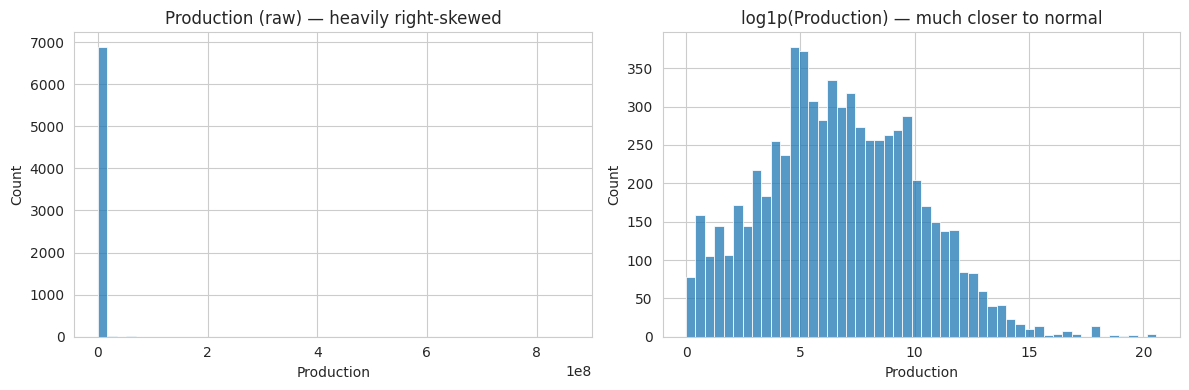

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data['Production'], bins=50, ax=axes[0])
axes[0].set_title('Production (raw) — heavily right-skewed')
sns.histplot(np.log1p(data['Production']), bins=50, ax=axes[1])
axes[1].set_title('log1p(Production) — much closer to normal')
plt.tight_layout()
plt.show()

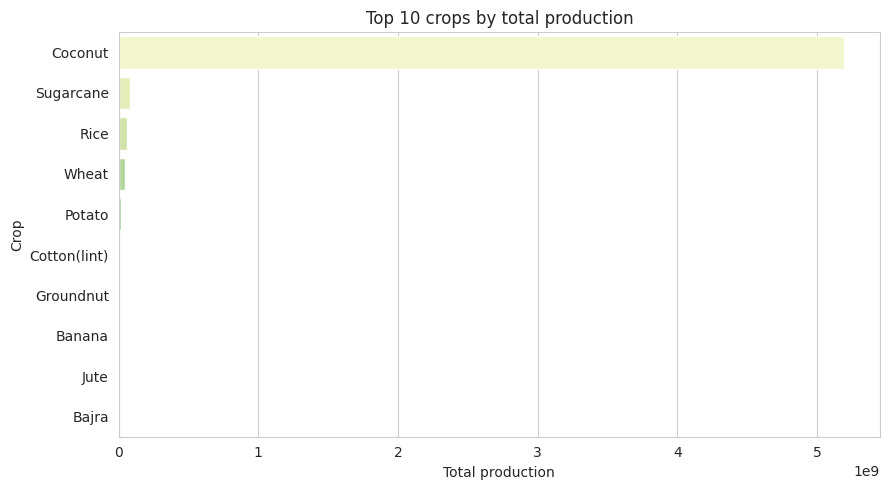

In [64]:
top_crops = data.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_crops.values, y=top_crops.index, hue=top_crops.index,
            palette='YlGn', legend=False)
plt.xlabel('Total production')
plt.title('Top 10 crops by total production')
plt.tight_layout()
plt.show()

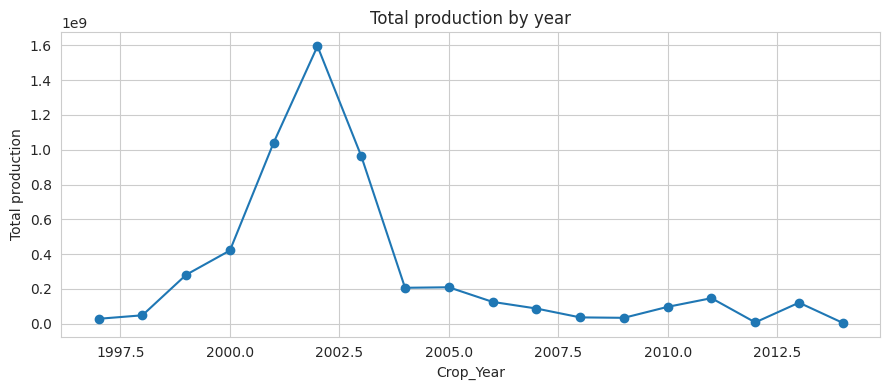

In [65]:
yearly = data.groupby('Crop_Year')['Production'].sum()

plt.figure(figsize=(9, 4))
yearly.plot(marker='o')
plt.ylabel('Total production')
plt.title('Total production by year')
plt.tight_layout()
plt.show()

## 5. Encode categorical features

In [66]:
state_map = {v: i for i, v in enumerate(sorted(data['State_Name'].unique()))}
season_map = {v: i for i, v in enumerate(sorted(data['Season'].unique()))}
crop_map = {v: i for i, v in enumerate(sorted(data['Crop'].unique()))}
data['state_code'] = data['State_Name'].map(state_map)
data['season_code'] = data['Season'].map(season_map)
data['crop_code'] = data['Crop'].map(crop_map)

## 6. Log-transform skewed columns

In [67]:
data['log_area'] = np.log1p(data['Area'])
data['log_production'] = np.log1p(data['Production'])

## 7. Correlation heatmap (numeric / encoded features)

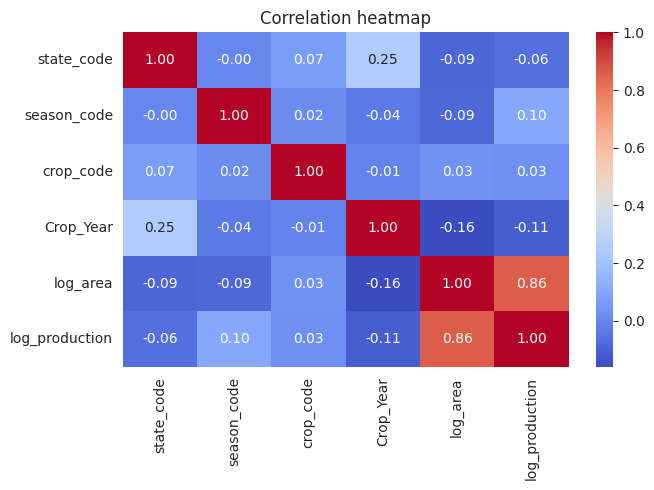

In [68]:
numeric_cols = ['state_code', 'season_code', 'crop_code', 'Crop_Year',                 'log_area', 'log_production']
plt.figure(figsize=(7, 5))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

## 8. Train / test split

In [69]:
features = ['state_code', 'season_code', 'crop_code', 'Crop_Year', 'log_area']
X = data[features]
y = data['log_production']  # model predicts log(Production); we invert at evaluation time
X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (5534, 5), Test: (1384, 5)


## 9. Train the model

In [70]:
model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=3, n_estimators=30,
                      n_jobs=-1, random_state=42)

## 10. EvaluateWe evaluate in **both** log space (what the model actually optimizes) and onthe original production scale (what actually matters to a user), since astrong log-space R² can still leave large absolute errors on huge values.

In [71]:
pred_log = model.predict(X_test)
pred = np.expm1(pred_log)
actual = np.expm1(y_test)
r2_log = r2_score(y_test, pred_log)
r2_real = r2_score(actual, pred)
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
print(f"R2 (log space):      {r2_log:.3f}")
print(f"R2 (original scale): {r2_real:.3f}")
print(f"MAE:                 {mae:,.0f}")
print(f"RMSE:                {rmse:,.0f}")

R2 (log space):      0.912
R2 (original scale): 0.573
MAE:                 164,032
RMSE:                2,346,519


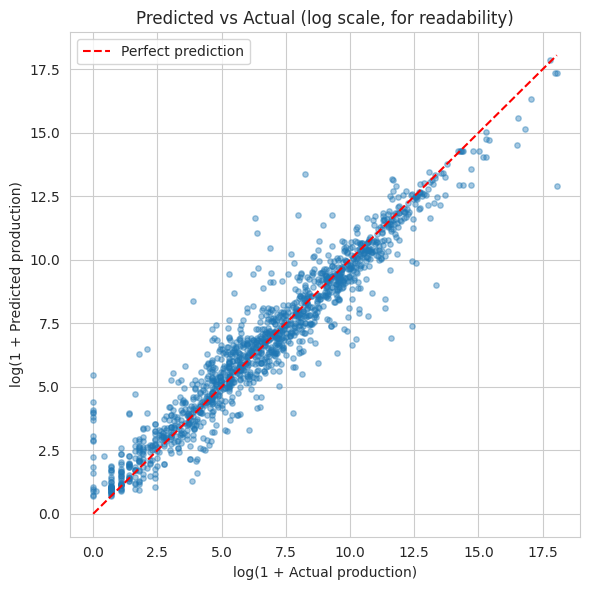

In [72]:
plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(actual), np.log1p(pred), alpha=0.4, s=15)
lims = [0, max(np.log1p(actual).max(), np.log1p(pred).max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('log(1 + Actual production)')
plt.ylabel('log(1 + Predicted production)')
plt.title('Predicted vs Actual (log scale, for readability)')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Feature importance

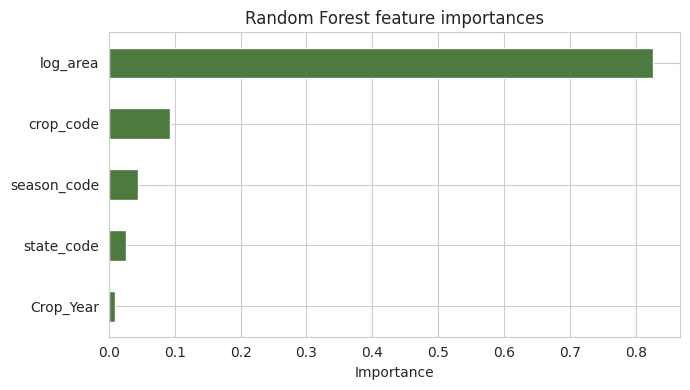

,0
Crop_Year,0.009741
state_code,0.026188
season_code,0.044750
crop_code,0.093378
log_area,0.825942


In [73]:
importances = pd.Series(model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='#4c7a3f')
plt.xlabel('Importance')
plt.title('Random Forest feature importances')
plt.tight_layout()
plt.show()
importances

**Takeaway:** `log_area` dominates — cultivated area explains most of thevariance in production, which matches agronomic intuition (more land undercultivation → proportionally more output for a given crop/season). Crop typeis the next largest driver, since different crops have very different yielddensities per unit area.

## 12. Save the trained model

In [74]:
import joblib
joblib.dump(model, 'crop_yield_rf_model.pkl')
joblib.dump({'state_map': state_map, 'season_map': season_map,
             'crop_map': crop_map, 'features': features},
            'crop_yield_encoders.pkl')
print("Saved model + encoders.")

Saved model + encoders.
